# Entrenamiento COMPLETO: Pancreatic CT (PANORAMA) — RTX 4090 / 24 GB RAM

**Modelo:** R3D18Pancreatic | **Tarea:** PDAC vs non-PDAC | **Semilla:** 42

## Estrategia para entrenar con TODOS los datos sin congelarse

El entrenamiento se divide en **dos fases** que sólo se ejecutan una vez cada una:

| Fase | Qué hace | Cuándo ejecutar |
|------|----------|-----------------|
| **0 — Conversión offline** | Convierte cada `.nii.gz` → tensor `.pt` preprocesado | **Una sola vez** antes de entrenar |
| **1 — Entrenamiento** | Lee `.pt` directamente, GPU siempre ocupada | Cada vez que entrenes |

> **Por qué se congela el original:** Leer NIfTI en cada época hace I/O lenta en cada `__getitem__`. Con todos los datos, los workers se saturan y la GPU espera disco. Al pre-convertir a `.pt`, cada sample tarda ~2 ms en cargarse en vez de ~200 ms.

## 1. Instalaciones

In [1]:
!pip install -q --root-user-action=ignore torch torchvision timm monai nibabel faiss-cpu scikit-learn huggingface_hub openpyxl kagglehub opencv-python seaborn

## 2. Imports

In [2]:
import os, warnings, hashlib, io, requests, zipfile
from contextlib import nullcontext
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
warnings.filterwarnings('ignore')

In [3]:
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt
import gc
import psutil

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve

In [5]:
from tqdm.notebook import tqdm as tqdm_nb
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torchvision.ops import sigmoid_focal_loss
from concurrent.futures import ProcessPoolExecutor, as_completed

## 3. Configuración Global

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU    : {props.name}')
    print(f'VRAM   : {props.total_memory / 1e9:.1f} GB')

Device : cuda
PyTorch: 2.11.0+cu130
GPU    : NVIDIA GeForce RTX 4090
VRAM   : 25.3 GB


## 3.1 Directorios

In [7]:
DATA_DIR            = Path('DATA')
DATA_PANCREATIC_DIR = DATA_DIR / 'pancreatic'
DATA_PLOTS_DIR      = DATA_DIR / 'plots'
# ── CACHE DE TENSORES ──────────────────────────────────────────────────
# Aquí se guardarán los .pt preprocesados (Fase 0).
# Con todos los datos PANORAMA (~500 estudios × ~30 MB/tensor) ≈ 15 GB en disco.
# Se necesita tener ≥ 20 GB libres en disco para el cache.
DATA_CACHE_DIR      = DATA_PANCREATIC_DIR / 'tensor_cache'

for _d in [DATA_PANCREATIC_DIR, DATA_PLOTS_DIR, DATA_CACHE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)
    print(f'  {_d}')

  DATA/pancreatic
  DATA/plots
  DATA/pancreatic/tensor_cache


## 4. Configuración PANORAMA

In [8]:
PANC_SEED        = 42

# ── USAR TODOS LOS DATOS ──────────────────────────────────────────────
# None = todos los estudios disponibles en disco tras la extracción.
# Esto funciona sin congelarse gracias a la cache de tensores .pt (Fase 0).
PANC_MAX_SAMPLES = None

# ── HIPERPARÁMETROS OPTIMIZADOS PARA RTX 4090 / 24 GB RAM ─────────────
PANC_BATCH_SIZE  = 8      # 4090 tiene 24 GB VRAM, batch 8 cabe con volúmenes 64³
PANC_NUM_WORKERS = 8      # Suficientes workers para que la GPU nunca espere
PANC_EPOCHS      = 30
PANC_LR          = 1e-4
PANC_FOCAL_ALPHA = 0.25
PANC_FOCAL_GAMMA = 2.0
PANC_ACCUM_STEPS = 2      # Reducido a 2 porque batch ya es 8
PANC_PATIENCE    = 7

PANC_HU_MIN, PANC_HU_MAX = -1000, 400
PANC_SIZE_3D     = (64, 64, 64)

PANC_ZENODO_ZIP_URL  = 'https://zenodo.org/api/records/13715870/files/batch_1.zip/content'
PANC_ZENODO_ZIP_MD5  = 'b3b3669a82696b954b449c27a9d85074'
PANC_LABELS_URL      = 'https://raw.githubusercontent.com/DIAGNijmegen/panorama_labels/main/clinical_information.xlsx'

## 5. Funciones Utilitarias

In [9]:
def preprocess_3d_volume(x, hu_min=PANC_HU_MIN, hu_max=PANC_HU_MAX, target_size=PANC_SIZE_3D):
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x).float()
    if x.ndim == 3:
        x = x.permute(2, 0, 1).unsqueeze(0)
    x = torch.clamp(x, hu_min, hu_max)
    x = (x - hu_min) / (hu_max - hu_min)
    return F.interpolate(
        x.unsqueeze(0), size=target_size, mode='trilinear', align_corners=False
    ).squeeze(0)


def load_panorama_labels(xlsx_path: str):
    df = pd.read_excel(xlsx_path, engine='openpyxl')
    labels = {
        str(row['PANORAMA_study_id']).strip(): int(str(row['label']).strip() == 'PDAC')
        for _, row in df.iterrows()
    }
    return df, labels


def download_with_progress(url: str, dest: Path, chunk_size: int = 1 << 20) -> None:
    resp = requests.get(url, stream=True, timeout=60)
    resp.raise_for_status()
    total = int(resp.headers.get('content-length', 0))
    with open(dest, 'wb') as fh, tqdm_nb(total=total, unit='B', unit_scale=True, unit_divisor=1024, desc=dest.name) as bar:
        for chunk in resp.iter_content(chunk_size=chunk_size):
            fh.write(chunk)
            bar.update(len(chunk))


def verify_md5(path: Path, expected: str) -> bool:
    h = hashlib.md5()
    with open(path, 'rb') as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b''):
            h.update(chunk)
    return h.hexdigest() == expected

## FASE 0 — Conversión offline NIfTI → tensor `.pt`

**Ejecutar una sola vez.** Convierte todos los `.nii.gz` a tensores `.pt` preprocesados y los guarda en `DATA_CACHE_DIR`. Una vez completado, el entrenamiento lee `.pt` directamente y la GPU nunca espera disco.

- Tiempo estimado: ~1–3 h para todos los datos PANORAMA (depende del disco)
- Espacio en disco: ~15–20 GB para el cache completo
- Si el cache ya existe, esta celda detecta los faltantes y sólo convierte los nuevos.

In [10]:
def convert_nii_to_pt(nii_path: Path, study_id: str, cache_dir: Path) -> tuple[str, bool]:
    """Convierte un NIfTI a tensor .pt. Retorna (study_id, éxito)."""
    out = cache_dir / f'{study_id}.pt'
    if out.exists():
        return study_id, True  # Ya convertido
    try:
        volume = nib.load(str(nii_path)).get_fdata(dtype=np.float32)
        tensor = preprocess_3d_volume(volume)
        torch.save(tensor, out)
        return study_id, True
    except Exception as e:
        print(f'  ERROR en {study_id}: {e}')
        return study_id, False


def run_offline_conversion(
    nii_paths: list[tuple[Path, str]],
    cache_dir: Path,
    max_workers: int = 6,   # Hilos paralelos de conversión
) -> list[str]:
    """
    Convierte todos los NIfTI a .pt en paralelo usando ThreadPoolExecutor.

    - max_workers=6: 6 hilos leen NIfTI en paralelo sin saturar RAM
      (cada volumen ocupa ~200–500 MB antes de resize; con 6 hilos = ~3 GB peak)
    - Retorna la lista de study_ids convertidos exitosamente.
    """
    pending = [(p, sid) for p, sid in nii_paths if not (cache_dir / f'{sid}.pt').exists()]
    already = len(nii_paths) - len(pending)

    if already:
        print(f'  Cache existente: {already} tensores ya convertidos.')
    if not pending:
        print('  Conversión completa, nada que hacer.')
        return [sid for _, sid in nii_paths]

    print(f'  Convirtiendo {len(pending)} NIfTI → .pt con {max_workers} workers...')
    print(f'  Destino: {cache_dir}')

    ok, fail = 0, 0
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {pool.submit(convert_nii_to_pt, p, sid, cache_dir): sid for p, sid in pending}
        with tqdm_nb(total=len(pending), desc='Convirtiendo NIfTI→.pt', unit='vol') as bar:
            for fut in as_completed(futures):
                _, success = fut.result()
                if success: ok += 1
                else: fail += 1
                bar.set_postfix(ok=ok, fail=fail)
                bar.update(1)

    print(f'  Resultado: {ok} OK, {fail} errores.')
    return [sid for _, sid in nii_paths if (cache_dir / f'{sid}.pt').exists()]

## 6. Dataset (lee sólo `.pt`)

In [11]:
class PancreaticCTDataset(Dataset):
    """
    Dataset que lee SÓLO tensores .pt preprocesados.
    NO lee NIfTI — eso ya fue hecho en la Fase 0.
    Carga ~2 ms/sample vs ~200 ms/sample con NIfTI.
    """
    DATASET_ID = 1

    def __init__(self, study_ids: list[str], label_dict: dict, cache_dir: Path = DATA_CACHE_DIR):
        # Sólo guarda study_ids que tienen .pt en cache
        self.items = [(sid, cache_dir / f'{sid}.pt') for sid in study_ids
                      if (cache_dir / f'{sid}.pt').exists()]
        self.label_dict = label_dict
        missing = len(study_ids) - len(self.items)
        if missing:
            print(f'  Advertencia: {missing} study_ids sin .pt en cache — excluidos.')

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        study_id, pt_path = self.items[idx]
        x = torch.load(pt_path, weights_only=True)
        y = torch.tensor(self.label_dict.get(study_id, -1), dtype=torch.long)
        return x, self.DATASET_ID, y

## 7. Modelo R3D18Pancreatic

In [12]:
class R3D18Pancreatic(nn.Module):
    """R3D-18 adaptado para CT pancreático (1 canal, clasificación binaria)."""

    def __init__(self, dropout: float = 0.3):
        super().__init__()
        from torchvision.models.video import r3d_18, R3D_18_Weights
        backbone = r3d_18(weights=R3D_18_Weights.KINETICS400_V1)
        old_conv = backbone.stem[0]
        new_conv = nn.Conv3d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size, stride=old_conv.stride,
            padding=old_conv.padding, bias=False,
        )
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.stem[0] = new_conv
        self.stem    = backbone.stem
        self.layer1  = backbone.layer1
        self.layer2  = backbone.layer2
        self.layer3  = backbone.layer3
        self.layer4  = backbone.layer4
        self.avgpool = backbone.avgpool
        self.head    = nn.Sequential(nn.Dropout(dropout), nn.Linear(backbone.fc.in_features, 1))

    def forward(self, x):
        x = self.stem(x)
        x = torch.utils.checkpoint.checkpoint(self.layer1, x, use_reentrant=False)
        x = torch.utils.checkpoint.checkpoint(self.layer2, x, use_reentrant=False)
        x = torch.utils.checkpoint.checkpoint(self.layer3, x, use_reentrant=False)
        x = torch.utils.checkpoint.checkpoint(self.layer4, x, use_reentrant=False)
        x = self.avgpool(x)
        return self.head(x.flatten(1)).squeeze(1)

## 12. Pipeline PANORAMA completo

### 12.1 Descargar datos

In [13]:
torch.manual_seed(PANC_SEED)
np.random.seed(PANC_SEED)
PIN_MEMORY = torch.cuda.is_available()

_panc_zip_path    = DATA_PANCREATIC_DIR / 'batch_1.zip'
_panc_extract_dir = DATA_PANCREATIC_DIR / 'batch_1'
_cached_nii       = list(DATA_PANCREATIC_DIR.rglob('*.nii.gz'))

print(f'NIfTI ya en disco: {len(_cached_nii)}')

if not _cached_nii:
    # Descarga completa del ZIP
    if not _panc_zip_path.exists():
        print('Descargando batch_1.zip (~46 GB)...')
        download_with_progress(PANC_ZENODO_ZIP_URL, _panc_zip_path)
        assert verify_md5(_panc_zip_path, PANC_ZENODO_ZIP_MD5), 'MD5 mismatch'
        print('  MD5 OK.')
    # Extracción completa
    print('Extrayendo ZIP completo...')
    _panc_extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(_panc_zip_path, 'r') as zf:
        nii_members = [m for m in zf.namelist() if m.endswith('.nii.gz')]
        for m in tqdm_nb(nii_members, desc='Extrayendo NIfTI', unit='file'):
            zf.extract(m, DATA_PANCREATIC_DIR)
    _cached_nii = list(DATA_PANCREATIC_DIR.rglob('*.nii.gz'))
    print(f'Extracción completa: {len(_cached_nii)} NIfTI.')
else:
    print('NIfTI ya extraídos, omitiendo descarga.')

NIfTI ya en disco: 557
NIfTI ya extraídos, omitiendo descarga.


In [14]:
# Labels
_panc_labels_xlsx = DATA_PANCREATIC_DIR / 'training_labels.xlsx'
if not _panc_labels_xlsx.exists():
    print('Descargando labels desde GitHub...')
    _resp = requests.get(PANC_LABELS_URL, timeout=30)
    _resp.raise_for_status()
    _panc_labels_xlsx.write_bytes(_resp.content)

df_panorama, panc_labels = load_panorama_labels(str(_panc_labels_xlsx))
print(f'Labels: {len(panc_labels)} estudios | PDAC: {sum(panc_labels.values())} | '
      f'non-PDAC: {sum(1 for v in panc_labels.values() if v == 0)}')

Labels: 2238 estudios | PDAC: 676 | non-PDAC: 1562


### 12.2 Indexar NIfTI y aplicar FASE 0

In [16]:
# ── Indexar directamente los .pt en cache ─────────────────────────────
_local_by_study: dict[str, Path] = {}

for _pt in DATA_CACHE_DIR.glob("*.pt"):
    _sid = _pt.stem  # nombre del archivo sin extensión
    _local_by_study[_sid] = _pt

print(f'Estudios con .pt encontrados: {len(_local_by_study)}')


# ── Limitar al muestreo si aplica ────────────────────────────────────
if PANC_MAX_SAMPLES is not None:
    rng = np.random.default_rng(PANC_SEED)
    _all_sids = list(_local_by_study.keys())
    _sel = rng.choice(
        _all_sids,
        size=min(PANC_MAX_SAMPLES, len(_all_sids)),
        replace=False
    )
    _local_by_study = {k: _local_by_study[k] for k in _sel}
    print(f'  Limitado a {len(_local_by_study)} estudios (PANC_MAX_SAMPLES={PANC_MAX_SAMPLES})')


# Mantener mismo formato que antes
all_pt_pairs = list(_local_by_study.items())  # [(sid, Path), ...]

print(f'Total .pt listos para usar: {len(all_pt_pairs)}')

Estudios con .pt encontrados: 555
Total .pt listos para usar: 555


### 12.3 Split train/val y DataLoaders

In [17]:
# Sólo usar los study_ids que tienen .pt en cache
_all_ids_with_cache = [sid for sid in _local_by_study if (DATA_CACHE_DIR / f'{sid}.pt').exists()]
_all_targets = [panc_labels.get(sid, 0) for sid in _all_ids_with_cache]

print(f'Estudios con cache .pt: {len(_all_ids_with_cache)}')

if len(set(_all_targets)) > 1 and len(_all_ids_with_cache) >= 4:
    _train_ids, _val_ids = train_test_split(
        _all_ids_with_cache, test_size=0.25,
        random_state=PANC_SEED, stratify=_all_targets,
    )
else:
    _train_ids, _val_ids = _all_ids_with_cache, _all_ids_with_cache

print(f'  Train: {len(_train_ids)} | Val: {len(_val_ids)}')

ds_train = PancreaticCTDataset(_train_ids, panc_labels)
ds_val   = PancreaticCTDataset(_val_ids,   panc_labels)

# ── DataLoaders optimizados para RTX 4090 ─────────────────────────────
# persistent_workers: evita recrear 8 workers en cada época (~5 s de overhead)
# prefetch_factor=3 : cada worker mantiene 3 batches listos en cola
# pin_memory        : copia a memoria fija para transferencia GPU más rápida
dl_train = DataLoader(
    ds_train, batch_size=PANC_BATCH_SIZE, shuffle=True,
    num_workers=PANC_NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True, prefetch_factor=3,
)
dl_val = DataLoader(
    ds_val, batch_size=PANC_BATCH_SIZE, shuffle=False,
    num_workers=PANC_NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=True, prefetch_factor=3,
)

x3d, _, y3d = next(iter(dl_train))
print(f'Batch shape: {x3d.shape} | Labels: {y3d.tolist()[:8]}')

Estudios con cache .pt: 555
  Train: 416 | Val: 139
Batch shape: torch.Size([8, 1, 64, 64, 64]) | Labels: [1, 0, 0, 0, 0, 0, 1, 0]


### 12.4 Modelo y optimizador

In [18]:
expert_3d = R3D18Pancreatic().to(DEVICE)
print(f'R3D18Pancreatic params: {sum(p.numel() for p in expert_3d.parameters()):,}')

optimizer_3d = torch.optim.AdamW(expert_3d.parameters(), lr=PANC_LR, weight_decay=1e-4)
# OneCycleLR: acelera convergencia con todos los datos
scheduler_3d = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_3d, max_lr=PANC_LR * 10,
    steps_per_epoch=len(dl_train), epochs=PANC_EPOCHS,
)
scaler_3d    = GradScaler(enabled=(DEVICE.type == 'cuda'))
autocast_ctx = lambda: (
    autocast(device_type='cuda', dtype=torch.float16)
    if DEVICE.type == 'cuda' else nullcontext()
)

R3D18Pancreatic params: 33,147,969


### 12.5 Training loop

In [19]:
best_f1_3d = 0.0
history_3d = []
_patience_counter = 0

for epoch in range(1, PANC_EPOCHS + 1):
    expert_3d.train()
    optimizer_3d.zero_grad(set_to_none=True)
    running_loss = 0.0
    y_true_epoch, y_pred_epoch = [], []
    step = 0

    for x, _, y in dl_train:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True).float()

        with autocast_ctx():
            logits = expert_3d(x)
            loss = sigmoid_focal_loss(
                logits, y, alpha=PANC_FOCAL_ALPHA, gamma=PANC_FOCAL_GAMMA, reduction='mean'
            ) / PANC_ACCUM_STEPS

        scaler_3d.scale(loss).backward()
        step += 1

        if step % PANC_ACCUM_STEPS == 0:
            scaler_3d.unscale_(optimizer_3d)
            torch.nn.utils.clip_grad_norm_(expert_3d.parameters(), max_norm=1.0)
            scaler_3d.step(optimizer_3d)
            scaler_3d.update()
            optimizer_3d.zero_grad(set_to_none=True)
            scheduler_3d.step()

        running_loss += loss.item() * PANC_ACCUM_STEPS * x.size(0)
        preds = (torch.sigmoid(logits.detach()) > 0.5).int().cpu().numpy()
        y_true_epoch.append(y.cpu().numpy().astype(int))
        y_pred_epoch.append(preds)

    if step % PANC_ACCUM_STEPS != 0:
        scaler_3d.unscale_(optimizer_3d)
        torch.nn.utils.clip_grad_norm_(expert_3d.parameters(), max_norm=1.0)
        scaler_3d.step(optimizer_3d)
        scaler_3d.update()
        optimizer_3d.zero_grad(set_to_none=True)

    y_true_all = np.concatenate(y_true_epoch)
    y_pred_all = np.concatenate(y_pred_epoch)
    epoch_loss = running_loss / len(ds_train)
    f1_train   = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)

    # Validación
    expert_3d.eval()
    _vt, _vp = [], []
    with torch.no_grad():
        for xv, _, yv in dl_val:
            xv = xv.to(DEVICE, non_blocking=True)
            with autocast_ctx():
                _lv = expert_3d(xv)
            _vp.append((torch.sigmoid(_lv).cpu().numpy() > 0.5).astype(int))
            _vt.append(yv.numpy().astype(int))
    f1_val = f1_score(np.concatenate(_vt), np.concatenate(_vp), average='macro', zero_division=0)

    history_3d.append({'epoch': epoch, 'loss': epoch_loss, 'f1_train': f1_train, 'f1_val': f1_val})
    lr_now = scheduler_3d.get_last_lr()[0]
    print(f'[3D] Epoch {epoch:02d}/{PANC_EPOCHS} | loss={epoch_loss:.4f} | '
          f'F1_train={f1_train:.4f} | F1_val={f1_val:.4f} | lr={lr_now:.2e}')

    if f1_val > best_f1_3d:
        best_f1_3d = f1_val
        _patience_counter = 0
        torch.save({'model_state': expert_3d.state_dict(), 'epoch': epoch}, 'experto_pancreatic_best.pt')
        print(f'  -> Nuevo mejor F1_val={best_f1_3d:.4f} guardado')
    else:
        _patience_counter += 1
        if _patience_counter >= PANC_PATIENCE:
            print(f'  EarlyStopping activado (mejor F1_val={best_f1_3d:.4f})')
            break

print(f'\nBest Val F1 Macro: {best_f1_3d:.4f}')

[3D] Epoch 01/30 | loss=0.1201 | F1_train=0.5651 | F1_val=0.6450 | lr=4.73e-05
  -> Nuevo mejor F1_val=0.6450 guardado
[3D] Epoch 02/30 | loss=0.0490 | F1_train=0.7634 | F1_val=0.6665 | lr=6.91e-05
  -> Nuevo mejor F1_val=0.6665 guardado
[3D] Epoch 03/30 | loss=0.0242 | F1_train=0.8636 | F1_val=0.6713 | lr=1.05e-04
  -> Nuevo mejor F1_val=0.6713 guardado
[3D] Epoch 04/30 | loss=0.0224 | F1_train=0.8949 | F1_val=0.7612 | lr=1.53e-04
  -> Nuevo mejor F1_val=0.7612 guardado
[3D] Epoch 05/30 | loss=0.0326 | F1_train=0.8349 | F1_val=0.5311 | lr=2.12e-04
[3D] Epoch 06/30 | loss=0.0462 | F1_train=0.7934 | F1_val=0.4870 | lr=2.81e-04
[3D] Epoch 07/30 | loss=0.0372 | F1_train=0.7562 | F1_val=0.6079 | lr=3.57e-04
[3D] Epoch 08/30 | loss=0.0425 | F1_train=0.7679 | F1_val=0.6301 | lr=4.38e-04
[3D] Epoch 09/30 | loss=0.0255 | F1_train=0.8316 | F1_val=0.6819 | lr=5.22e-04
[3D] Epoch 10/30 | loss=0.0285 | F1_train=0.8833 | F1_val=0.6218 | lr=6.05e-04
[3D] Epoch 11/30 | loss=0.0250 | F1_train=0.8479 |

### 12.6 Evaluación final

In [20]:
expert_3d.load_state_dict(
    torch.load('experto_pancreatic_best.pt', weights_only=False)['model_state']
)
expert_3d.eval()

y_true_3d, y_pred_3d, panc_probs = [], [], []
with torch.no_grad():
    for x, _, y in dl_val:
        x = x.to(DEVICE, non_blocking=True)
        with autocast_ctx():
            logits = expert_3d(x)
        probs = torch.sigmoid(logits).cpu().numpy()
        y_true_3d.append(y.numpy().astype(int))
        y_pred_3d.append((probs > 0.5).astype(int))
        panc_probs.append(probs)

y_true_3d  = np.concatenate(y_true_3d)
y_pred_3d  = np.concatenate(y_pred_3d)
panc_probs = np.concatenate(panc_probs)
f1_3d = f1_score(y_true_3d, y_pred_3d, average='macro', zero_division=0)

print(pd.DataFrame([{
    'expert': 'Expert 3D (R3D18)', 'metric': 'F1 Macro',
    'value': round(f1_3d, 4), 'target': '>= 0.65', 'passes': f1_3d >= 0.65
}]).to_string(index=False))

           expert   metric  value  target  passes
Expert 3D (R3D18) F1 Macro 0.7612 >= 0.65    True


### 12.7 Gráficos

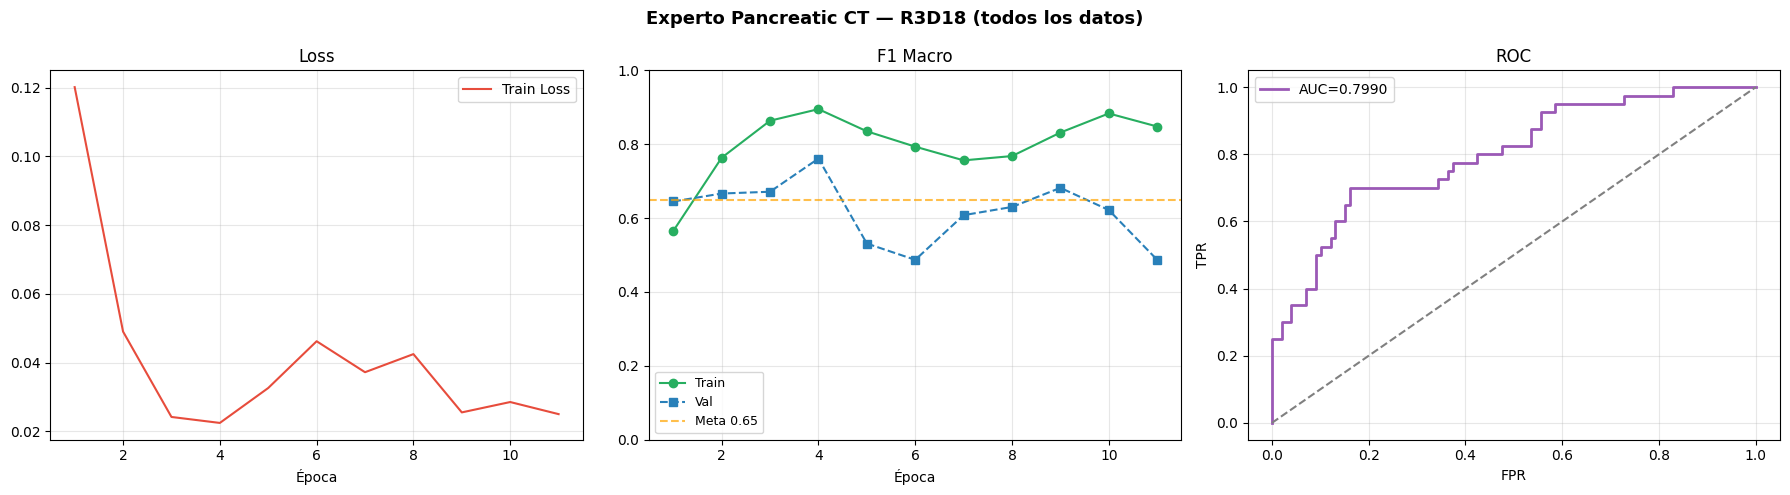

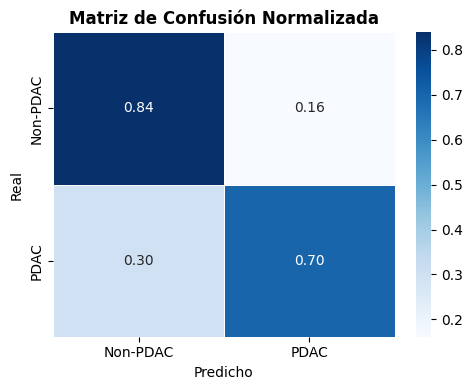

Gráficos guardados en DATA/plots


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Experto Pancreatic CT — R3D18 (todos los datos)', fontsize=13, fontweight='bold')

_ep = range(1, len(history_3d) + 1)
axes[0].plot(_ep, [h['loss'] for h in history_3d], color='#e74c3c', label='Train Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(_ep, [h['f1_train'] for h in history_3d], color='#27ae60', marker='o', label='Train')
axes[1].plot(_ep, [h['f1_val']   for h in history_3d], color='#2980b9', marker='s', ls='--', label='Val')
axes[1].axhline(0.65, color='orange', ls='--', alpha=0.7, label='Meta 0.65')
axes[1].set_title('F1 Macro'); axes[1].set_xlabel('Época'); axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

try:
    fpr, tpr, _ = roc_curve(y_true_3d, panc_probs)
    auc = roc_auc_score(y_true_3d, panc_probs)
    axes[2].plot(fpr, tpr, color='#9b59b6', lw=2, label=f'AUC={auc:.4f}')
    axes[2].plot([0,1],[0,1],'--',color='gray')
    axes[2].set_title('ROC'); axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
    axes[2].legend(); axes[2].grid(alpha=0.3)
except Exception as e:
    axes[2].text(0.5, 0.5, f'ROC no disponible\n{e}', ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.savefig(str(DATA_PLOTS_DIR / 'pancreatic_curvas.png'), dpi=130, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_true_3d, y_pred_3d, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Non-PDAC','PDAC'], yticklabels=['Non-PDAC','PDAC'],
            linewidths=0.5, ax=ax2)
ax2.set_title('Matriz de Confusión Normalizada', fontweight='bold')
ax2.set_ylabel('Real'); ax2.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig(str(DATA_PLOTS_DIR / 'pancreatic_confusion.png'), dpi=130, bbox_inches='tight')
plt.show()
print(f'Gráficos guardados en {DATA_PLOTS_DIR}')